In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.naive_bayes import BernoulliNB, ComplementNB
from collections import Counter
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import pandas as pd
import numpy as np
import h5py
from tqdm import tqdm
import joblib
import os

root = "."

In [7]:
# # Load smiles
# data = pd.read_csv(os.path.join(root, "..", "processed", "enamine_REAL_characterization", "enamine_REAL.tsv"), sep='\t')
# data['index'] = data.index
# ind_to_id = {i: j for i,j in data[['index', 'id']].values}
# id_to_ind = {i: j for i,j in data[['id', 'index']].values}

# # Define some paths
# PATH_TO_DOCKING_RESULTS_REAL = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'docking_results')
# PATH_TO_INPUT_LIGANDS = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'input_ligands')
PATH_TO_RESULTS = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'training_results')  # models and aurocs
# os.makedirs(os.path.join(PATH_TO_RESULTS, 'models'), exist_ok=True)
# os.makedirs(os.path.join(PATH_TO_RESULTS, 'aurocs'), exist_ok=True)

# # Load pocket detection data
# pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [ ]:
# # Load ECFPs
# with h5py.File(os.path.join(root, "..", "processed", "enamine_REAL_characterization", "enamine_REAL_ECFP6.h5")) as h5:
#     ids_ind = h5['ids'][:]
#     fps = h5['fps'][:]

# id_to_fp = {ind_to_id[i]:j for i,j in zip(ids_ind, fps)}
# del ids_ind, fps

In [ ]:
# # For each pocket
# for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL))):

#     # Load results
#     lines = open(os.path.join(PATH_TO_INPUT_LIGANDS, f"input_ligands_{pocket}.txt"), "r").readlines()
#     lines = [i.strip().replace(".sdf", "").split("/")[-1] for i in lines]
#     actives = set(lines[:100000])
#     inactives = set(lines[100000:])
#     scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL, pocket, 'report.csv'))
#     scores['set'] = ["inactive" if i in inactives else "active" for i in scores['compound']]
#     scores_actives = scores[scores['set'] == 'active'].reset_index(drop=True)
#     scores_inactives = scores[scores['set'] == 'inactive'].reset_index(drop=True)
#     DOCKING_RESULTS_REAL = {i: j for i, j in zip(scores_actives['compound'], scores_actives['score'])}
#     DOCKING_RESULTS_REAL_BACKGROUND = {i: j for i, j in zip(scores_inactives['compound'], scores_inactives['score'])}
#     del lines, actives, inactives, scores, scores_actives, scores_inactives

#     # Create matrix
#     docking_results = []
#     for act in sorted(DOCKING_RESULTS_REAL):
#         docking_results.append([act, DOCKING_RESULTS_REAL[act]])
#     for back in sorted(DOCKING_RESULTS_REAL_BACKGROUND):
#         docking_results.append([back, DOCKING_RESULTS_REAL_BACKGROUND[back]])
#     docking_results = pd.DataFrame(docking_results, columns=['id', 'score']).sort_values('score').reset_index(drop=True)
#     number_actives = 1130
#     docking_results['Y'] = [1] * number_actives + [0] * (len(docking_results) - number_actives)
#     compounds = np.array(docking_results['id'].tolist())
#     Y = np.array(docking_results['Y'].tolist())
#     X = np.array([id_to_fp[i] for i in compounds])
#     perm = np.random.permutation(len(X))
#     X, Y, compounds = X[perm], Y[perm], compounds[perm]
#     # print("Y mean (pos rate):", Y.mean(), "counts:", np.bincount(Y))

#     # Normalizing ECFP6s...
#     X = normalize(X, norm='l2')

#     # Train NB model
#     clf = ComplementNB()
#     clf.fit(X, Y)
#     y_score = clf.predict_proba(X)[:, 1]
#     auc = round(roc_auc_score(Y, y_score), 5)
#     print(f"{pocket} AUROC: {auc}")

#     # Save results
#     with open(os.path.join(PATH_TO_RESULTS, "aurocs", f"{pocket}_auroc.csv"), "w") as outfile:
#         outfile.write("auroc\n")
#         outfile.write(f"{auc}\n")

#     # Save model
#     joblib.dump(clf, os.path.join(PATH_TO_RESULTS, 'models', f"{pocket}_nb_model.joblib"))

In [8]:
AUROCS = []
for pocket in tqdm(sorted(os.listdir(os.path.join(PATH_TO_RESULTS, "aurocs")))):
    auroc = float(open(os.path.join(PATH_TO_RESULTS, "aurocs", pocket)).readlines()[1].strip())
    AUROCS.append(auroc)

AUROCS = np.array(AUROCS)[np.argsort(AUROCS)]

100%|██████████| 276/276 [06:00<00:00,  1.31s/it]


In [9]:
min(AUROCS), max(AUROCS)

(np.float64(0.81518), np.float64(0.96009))

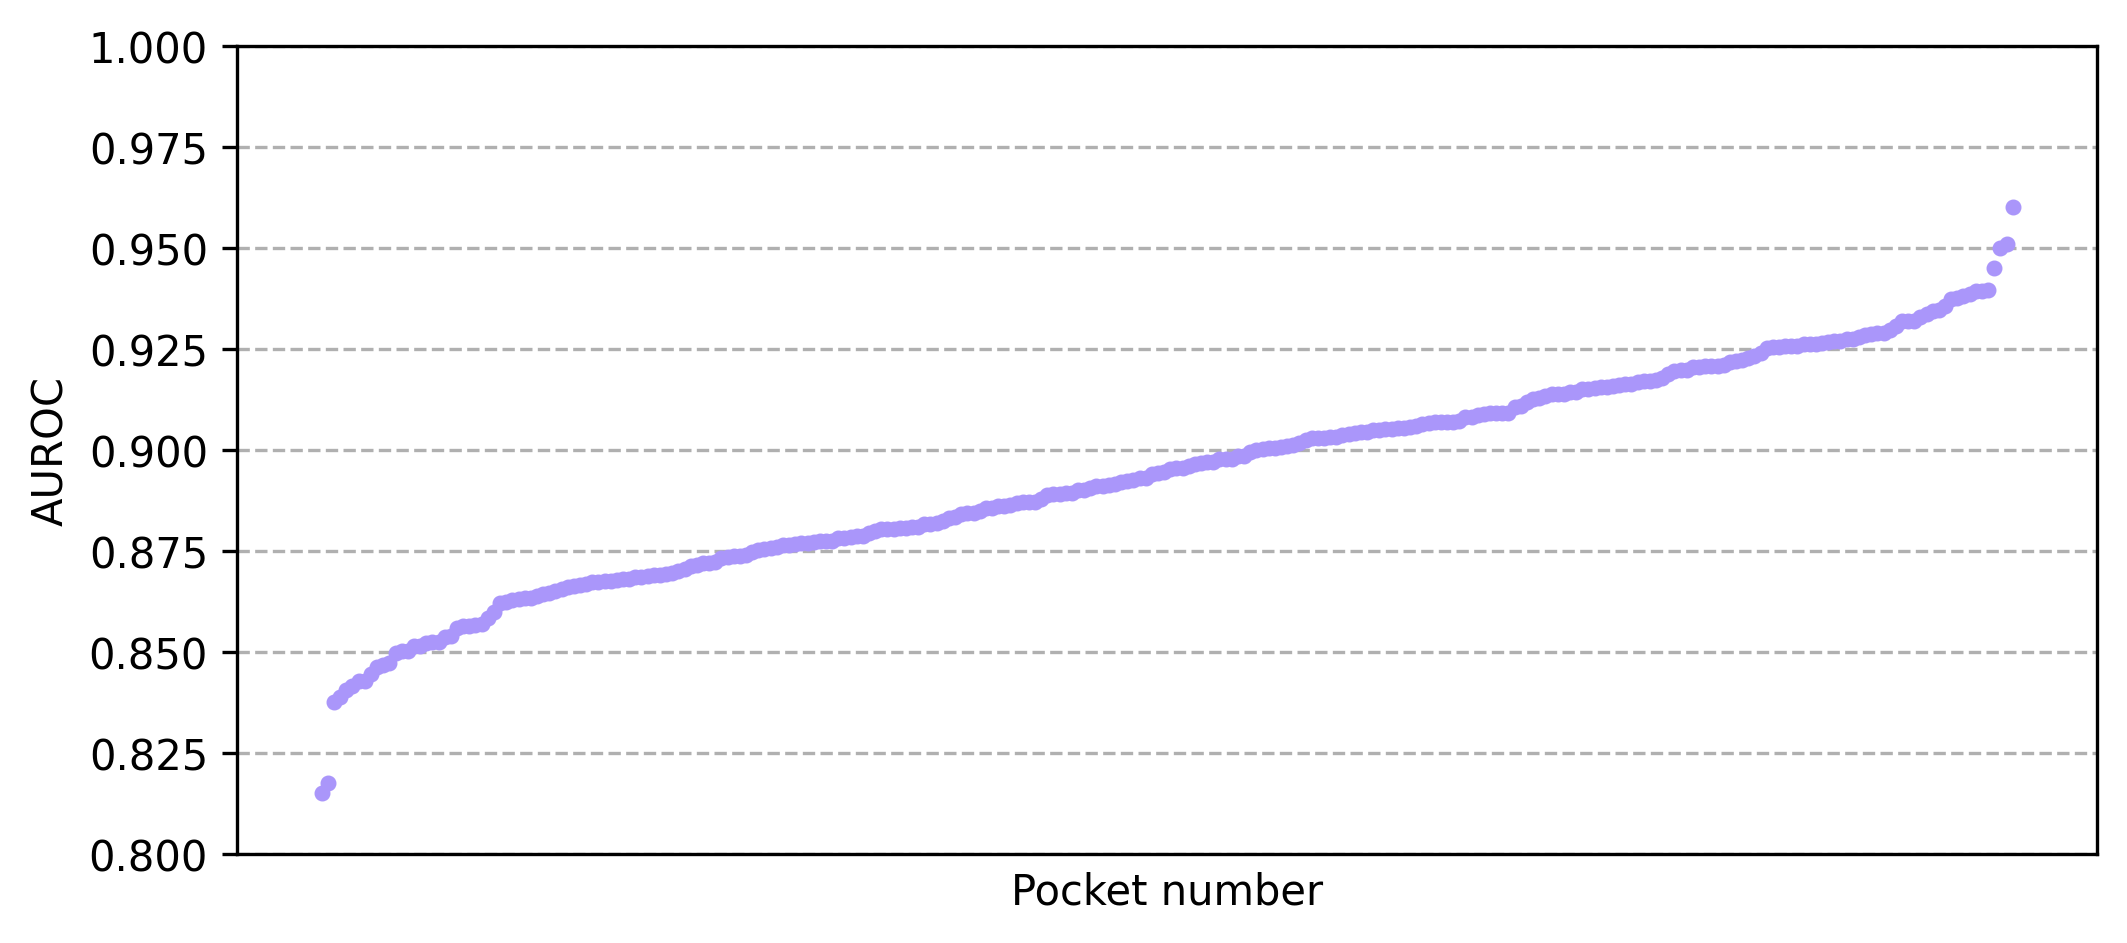

In [10]:
plt.figure(figsize=(8, 3.5))
plt.scatter([i for i in range(len(AUROCS))], AUROCS, s=8, zorder=2, c='#AA96FA')

plt.ylim([0.80, 1.00])
plt.ylabel("AUROC")
plt.xlabel("Pocket number")
plt.grid(linestyle='--')
plt.xticks([])
plt.show()